Dataset Name:  /content/cleaned_data.csv
Number of Rows: 463
Number of Columns: 13
Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

===== DATASET PREVIEW =====
     price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  9100000  6000         4          1        2      yes        no      yes   
1  9100000  6600         4          2        2      yes       yes      yes   
2  8890000  4600         3          2        2      yes       yes       no   
3  8855000  6420         3          2        2      yes        no       no   
4  8750000  4320         3          1        2      yes        no      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no              no        2       no   semi-furnished  
1              no             yes        1      yes      unfurnished  
2              no        

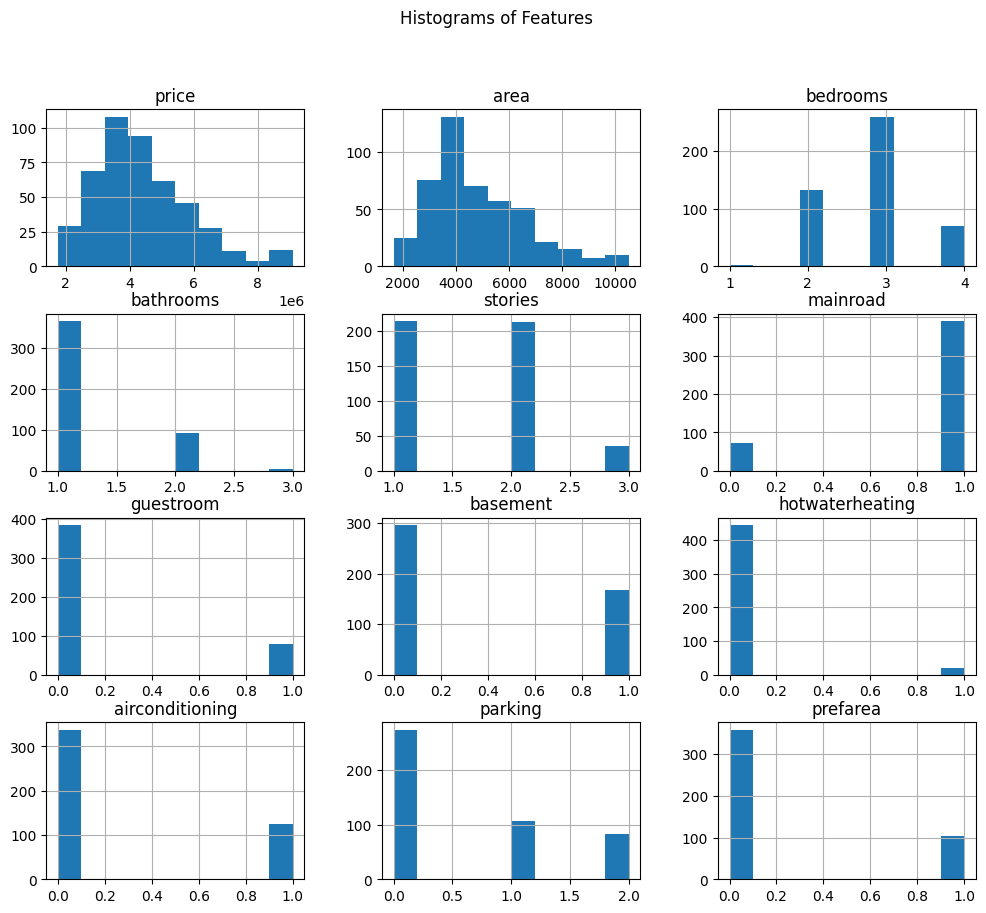

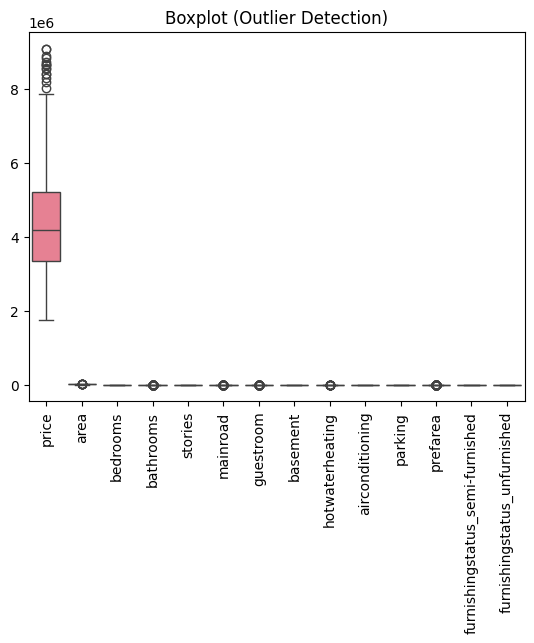

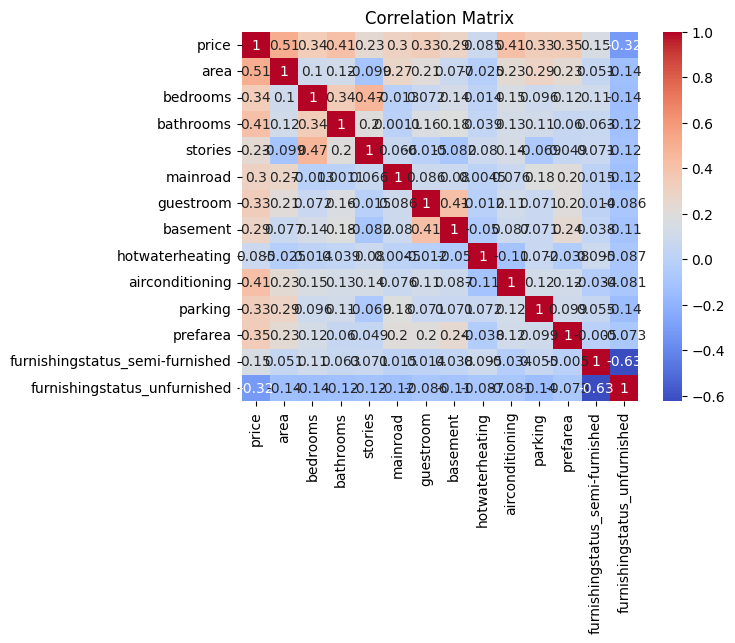

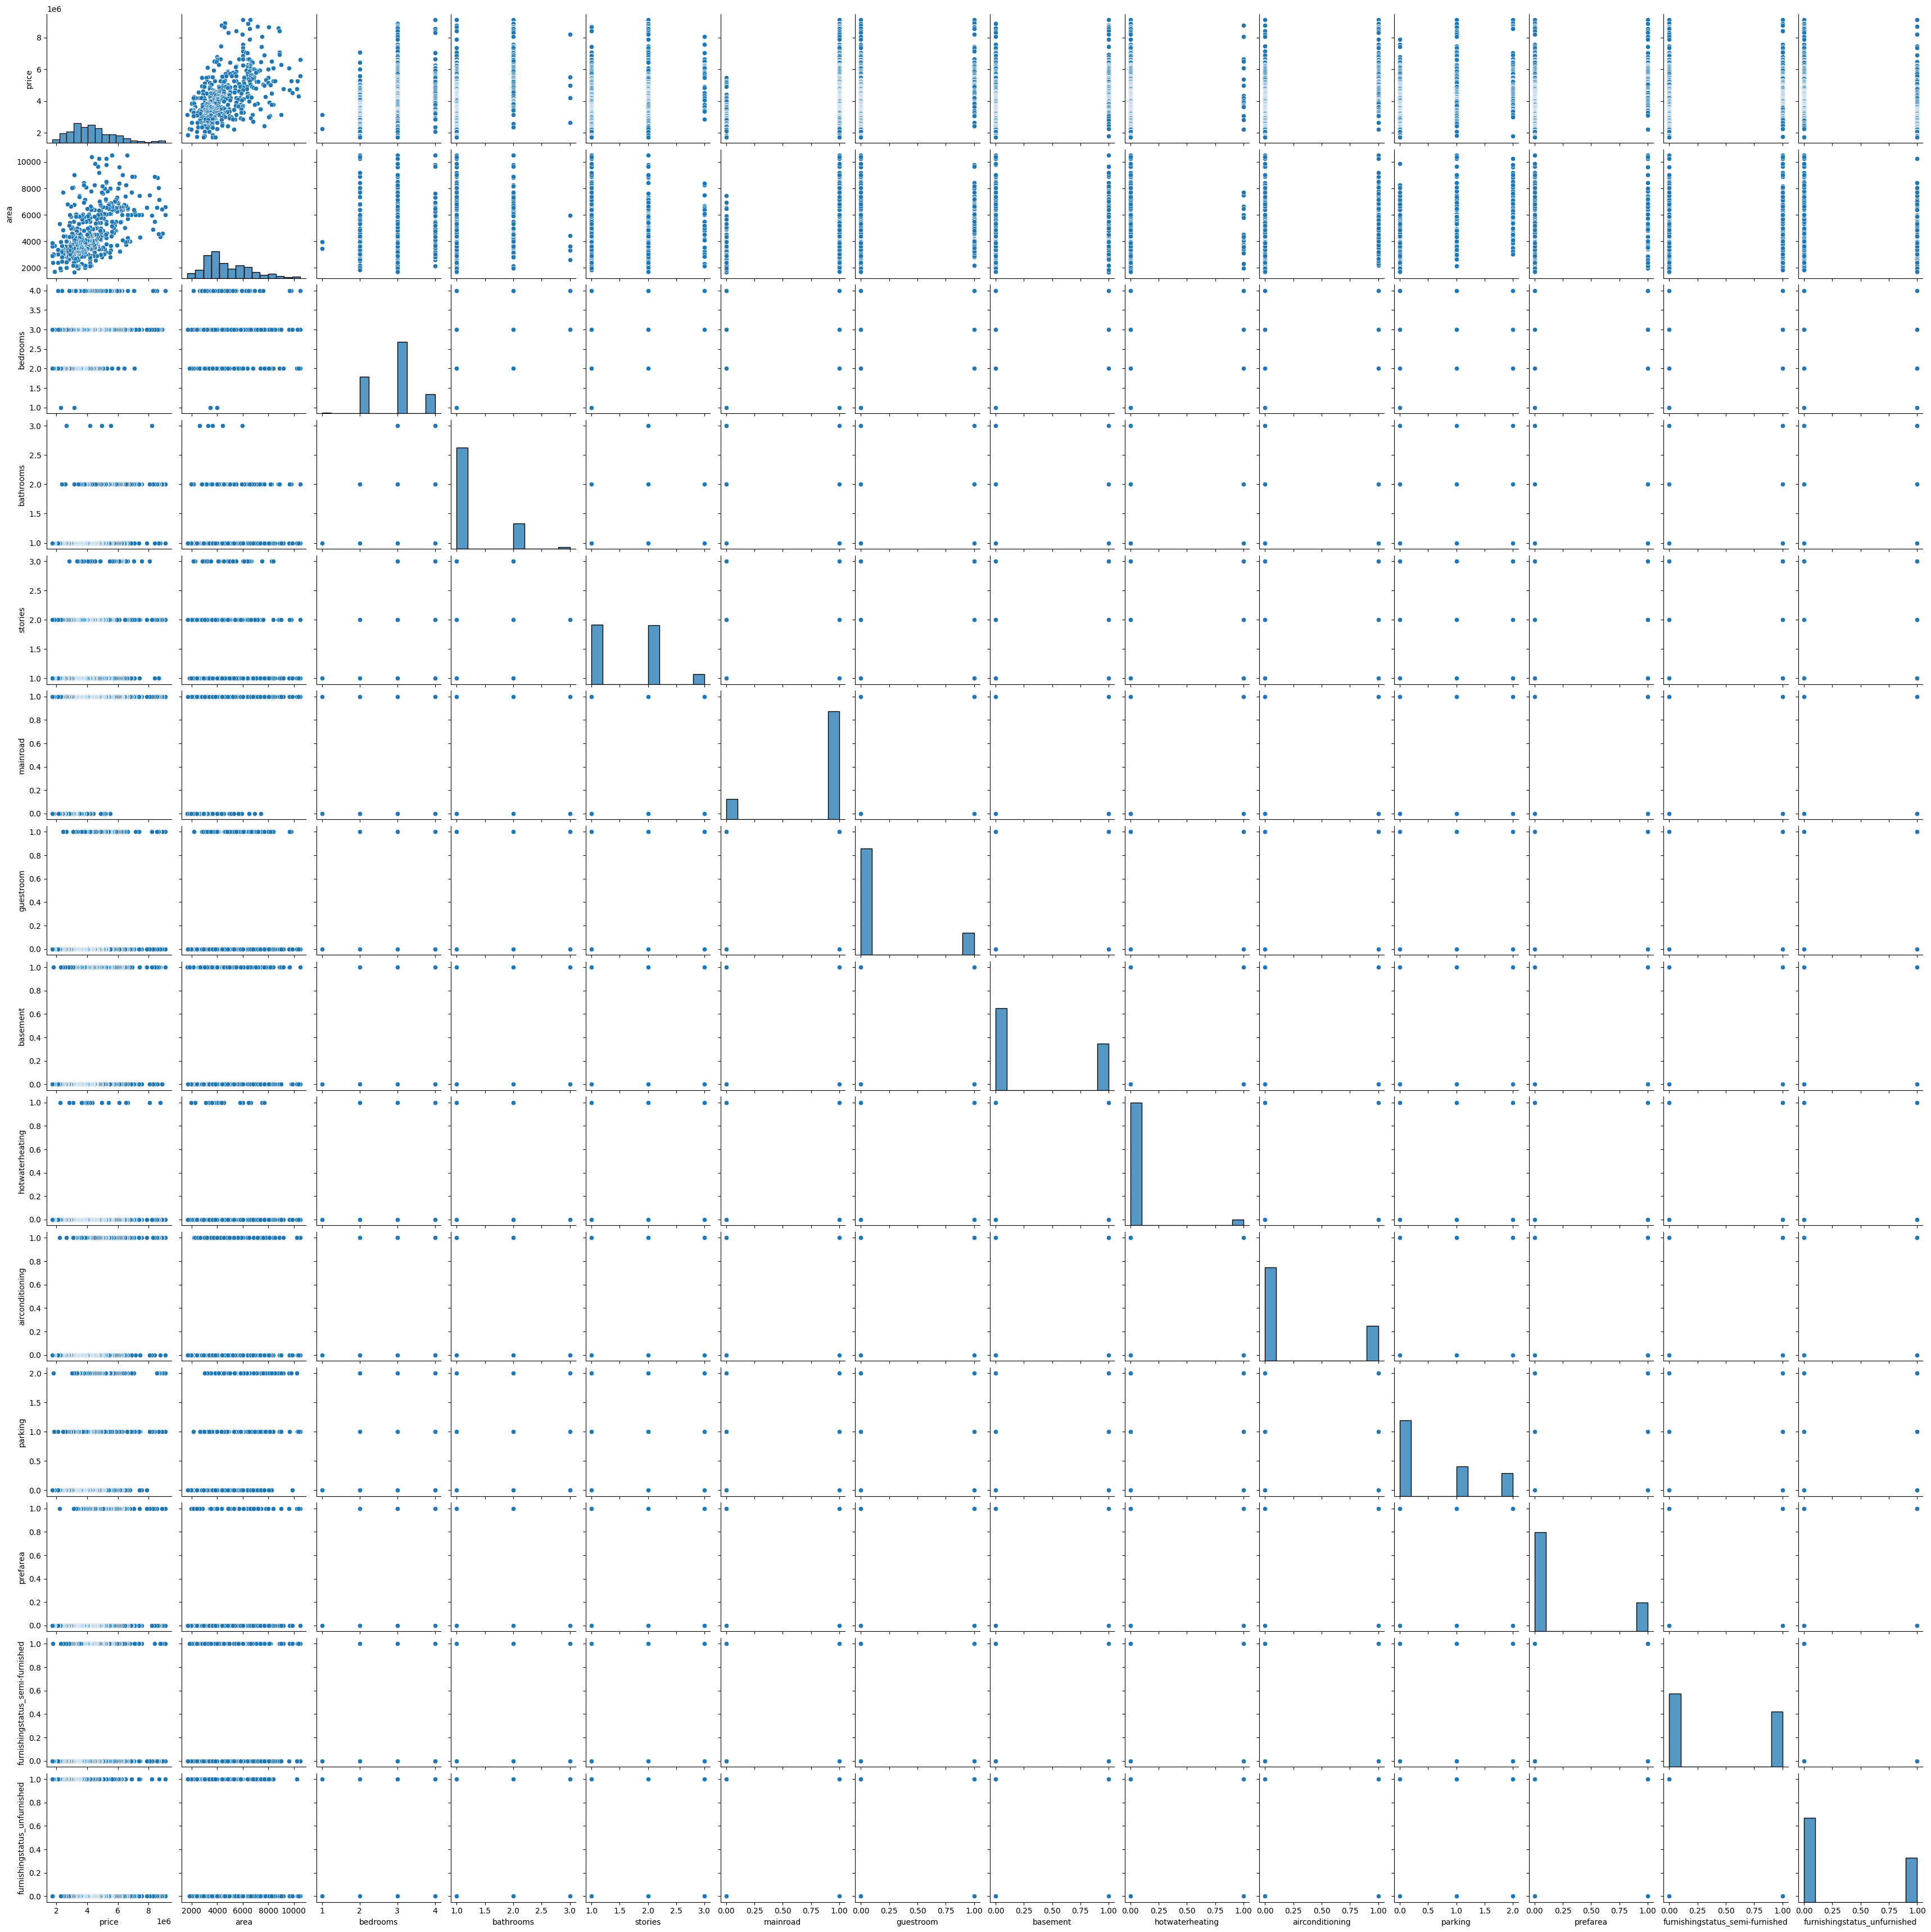

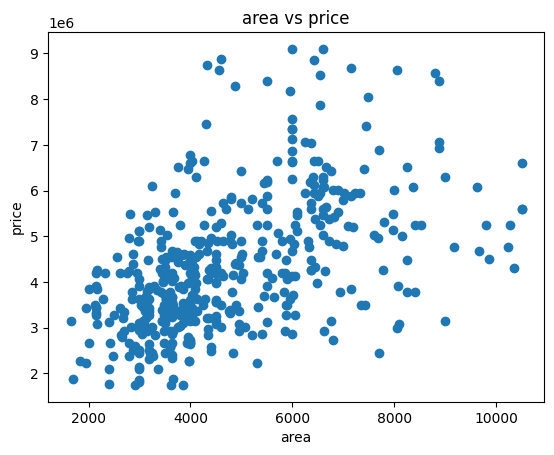

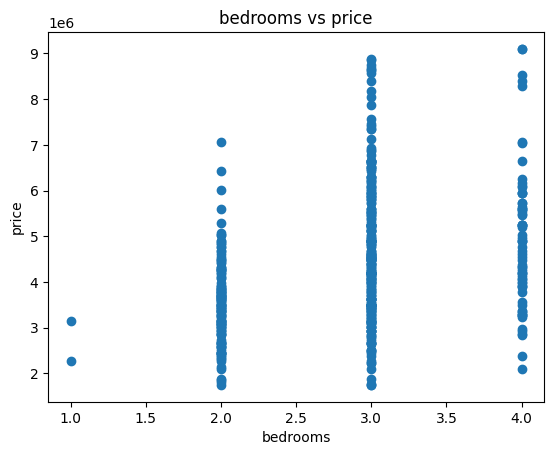

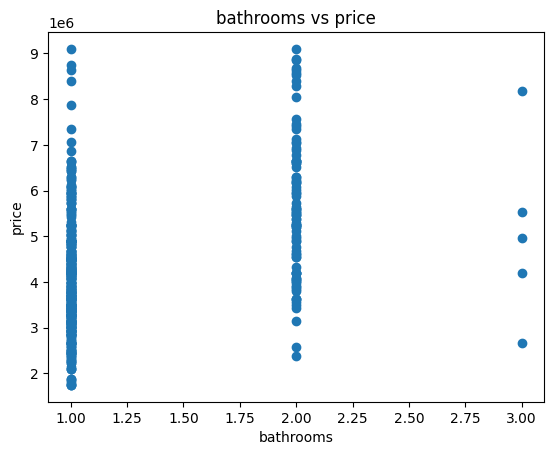

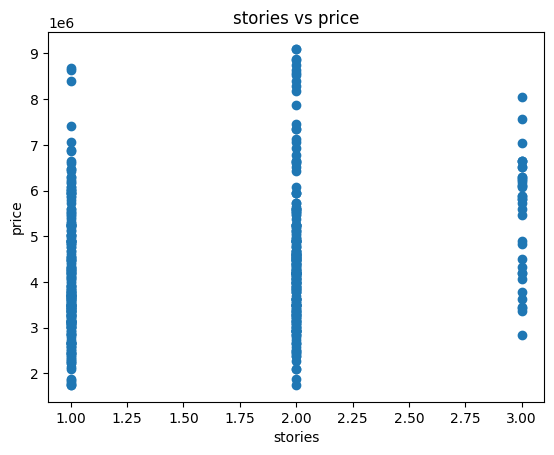

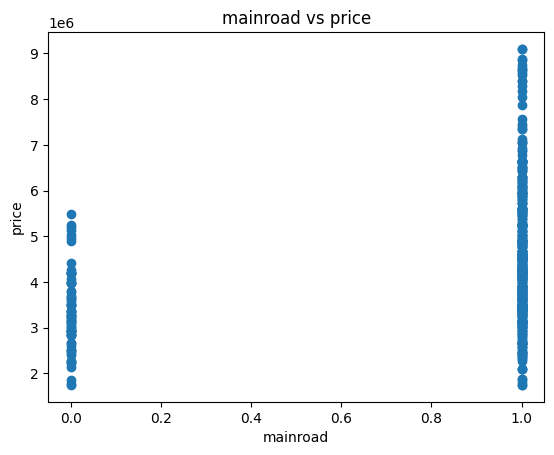

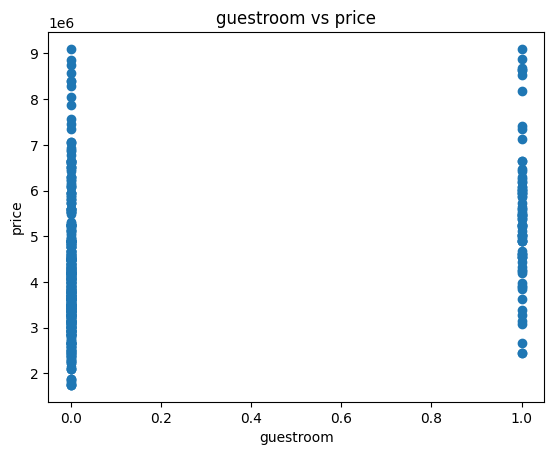

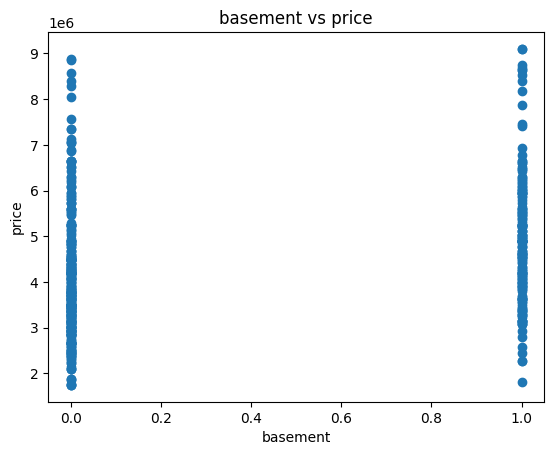

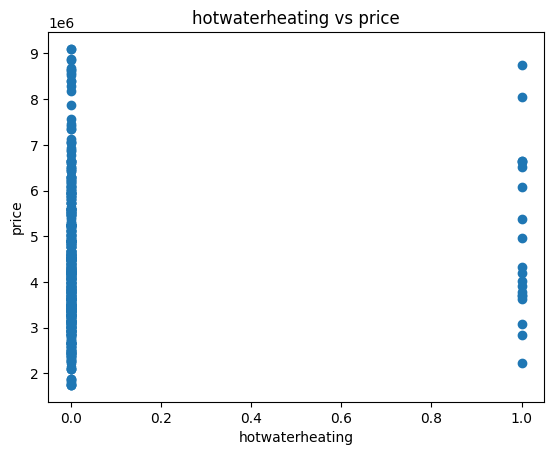

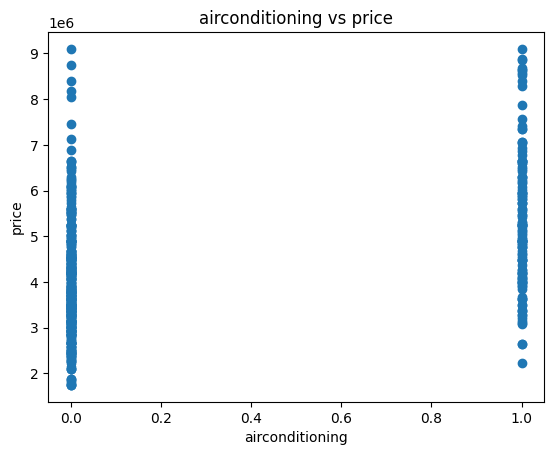

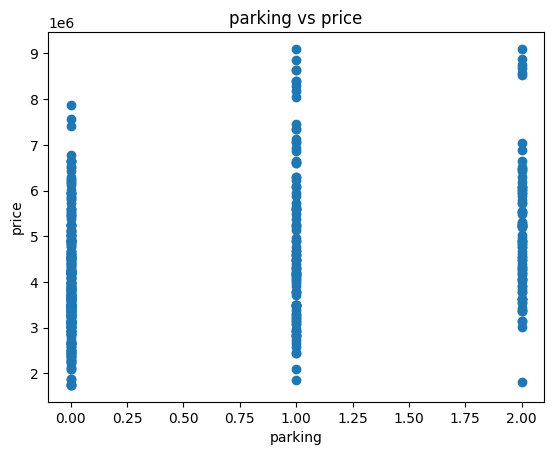

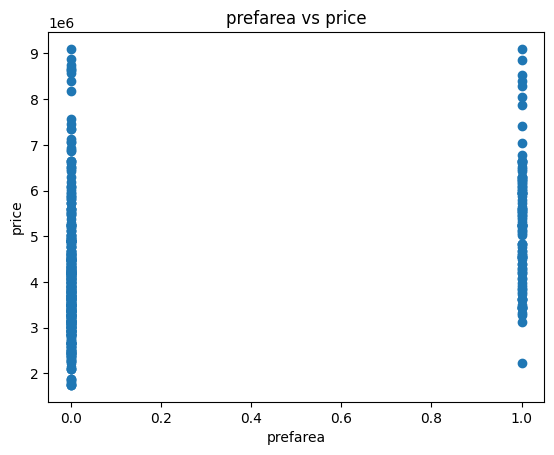

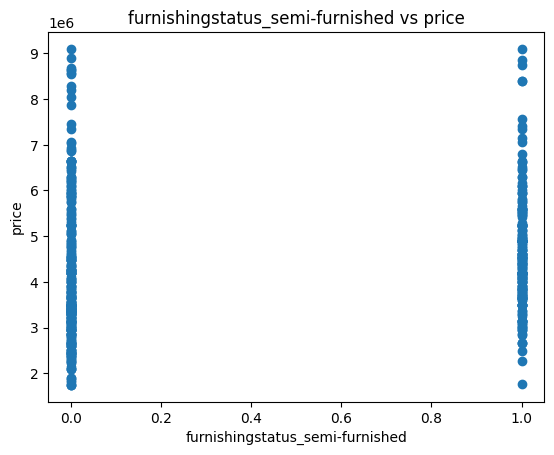

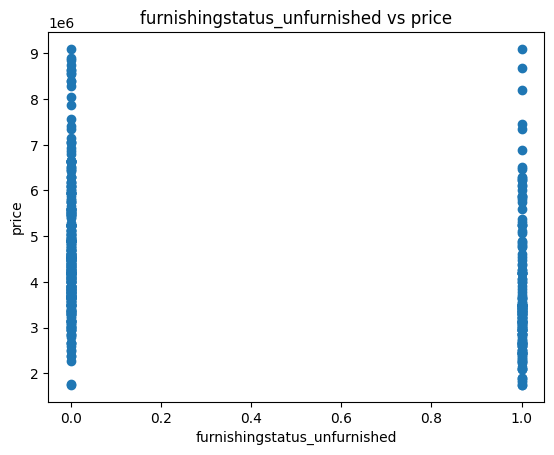

In [ ]:
# ==========================================
# STEP 1: Import Libraries
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 2: Load Dataset
# ==========================================
df = pd.read_csv("/content/cleaned_data.csv")   # 🔥 CHANGE FILE
print("Dataset Name: ", "/content/cleaned_data.csv")
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("Columns:", df.columns.tolist())

print("\n===== DATASET PREVIEW =====")
print(df.head())

# ==========================================
# STEP 3: Basic Information
# ==========================================
print("\n===== DATA INFO ====")
print(df.info())

print("\n===== STATISTICAL SUMMARY ====")
print(df.describe())

# ==========================================
# STEP 4: Missing Values
# ==========================================
print("\n===== MISSING VALUES ====")
print(df.isnull().sum())

# ==========================================
# STEP 5: Data Cleaning (optional)
# ==========================================
df = df.dropna()

# Convert binary categorical columns to numerical (0/1)
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].apply(lambda x: 1 if x == 'yes' else 0)

# Handle 'furnishingstatus' using one-hot encoding
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# ==========================================
# STEP 6: Univariate Analysis
# ==========================================

# Histogram for all numeric columns
df.hist(figsize=(12, 10))
plt.suptitle("Histograms of Features")
plt.show()

# ==========================================
# STEP 7: Boxplot (Outliers Detection)
# ==========================================
plt.figure()
sns.boxplot(data=df)
plt.title("Boxplot (Outlier Detection)")
plt.xticks(rotation=90)
plt.show()

# ==========================================
# STEP 8: Correlation Matrix
# ==========================================
plt.figure()
corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ==========================================
# STEP 9: Pairplot (Relationships)
# ==========================================
sns.pairplot(df)
plt.show()

# ==========================================
# STEP 10: Feature vs Target Analysis
# ==========================================
target = "price"   # Changed target column from 'target_column' to 'price'

for col in df.columns:
    if col != target:
        plt.figure()
        plt.scatter(df[col], df[target])
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(f"{col} vs {target}")
        plt.show()